<a href="https://colab.research.google.com/github/soo423/MachineLearning/blob/main/Chapter04_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt #그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트 관리 모듈

#드라이브 내 폰트 경로
font_path = "/content/drive/MyDrive/Colab_Notebooks/kwu/bigdata/dataPreProcessing/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


### 앙상블 학습 - 보팅 분류기(Voting Classifier)

In [ ]:
bc = '/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/Breast_Cancer.csv'

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import VotingClassifier #앙상블 학습 기법 중 하나
from sklearn.linear_model import LogisticRegression #로지스틱 회귀 모델
from sklearn.neighbors import KNeighborsClassifier #K-최근접 아웃 분류 모델
from sklearn.datasets import load_breast_cancer #유방암 데이터셋
from sklearn.model_selection import train_test_split #데이터셋을 훈련 세트와 테스트 세트로 분할
from sklearn.metrics import accuracy_score #모델의 정확도를 평가

In [ ]:
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
print('피처 수:', data_df.shape[1])
data_df.head(3)

피처 수: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
#소프트 보팅 기반 앙상블 구성
lr_clf = LogisticRegression(solver='liblinear', random_state=156) #로지스틱 회귀 분류기 객체
knn_clf = KNeighborsClassifier(n_neighbors=8)# K-최근접 이웃 분류기 객체

vo_clf = VotingClassifier( #VotingClassifier 객체
  estimators = [('lr', lr_clf), ('KNN', knn_clf)], #앙상블에 사용할 개별 모델 리스트
  voting = 'soft' #보팅 방식
)
#유방암 데이터를 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size = 0.2, random_state=156)

#보딩 앙상블 학습/평가
vo_clf.fit(X_train, y_train) #앙상블 모델 학습
pred = vo_clf.predict(X_test)#학습된 보팅 분류기를 사용하여 예측을 수행
print(f'보팅 분류기 정확도: {accuracy_score(y_test, pred):.4f}')

#개별 모델 성능과 비교
print('\n[개별 모델과 성능 비교]')
for clf in [lr_clf, knn_clf]:
  clf.fit(X_train, y_train)
  pred = clf.predict(X_test)
  print(f'{clf.__class__.__name__}: {accuracy_score(y_test, pred):.4f}')

보팅 분류기 정확도: 0.9561

[개별 모델과 성능 비교]
LogisticRegression: 0.9474
KNeighborsClassifier: 0.9386


### 랜덤 포레스트(Random Forest)

In [ ]:
#사용자 행동 인식 데이터로 실습

In [ ]:
import numpy as np
#중복 컬럼명 처리 함수
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(
      data= old_feature_name_df.groupby('column_name').cumcount(), #각 그룹 내에서 중복 횟수를 카운트
      columns=['dup_cnt'] #중복 횟수 컬럼의 이름
  )
  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  #중복 횟수가 0보다 크면 '원래이름_중복횟수, '아니면 원래이름'
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
      lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1
  )
  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

In [ ]:
# UCI 사용자 행동 인식 데이터셋을 로드
feature_name_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/human_activity/features.txt', sep='\s+',
                              header=None, names=['column_index','column_name'])
feature_name_df

feature_dup_df = pd.DataFrame(
    data=feature_name_df.groupby('column_name').cumcount(), #각 그룹 내에서 중복 횟수를 카운트
    columns=['dup_cnt'] # 중복 횟수 컬럼의 이름
)
feature_dup_df = feature_dup_df.reset_index()
feature_dup_df

,index,dup_cnt
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
556,556,0
557,557,0
558,558,0
559,559,0


In [ ]:
new_feature_name_df = pd.merge(feature_name_df.reset_index(),feature_dup_df, how='outer')
# 중복 횟수가 0보다 크면 '원래이름_중복횟수', 아니면 '원래이름'
new_feature_name_df['column_name'] = new_feature_name_df[['column_name','dup_cnt']].apply(
lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1
)

In [ ]:
new_feature_name_df = new_feature_name_df.drop(['index'], axis=1) # 컬럼 삭제
new_feature_name_df

,column_index,column_name,dup_cnt
0,1,tBodyAcc-mean()-X,0
1,2,tBodyAcc-mean()-Y,0
2,3,tBodyAcc-mean()-Z,0
3,4,tBodyAcc-std()-X,0
4,5,tBodyAcc-std()-Y,0
...,...,...,...
556,557,"angle(tBodyGyroMean,gravityMean)",0
557,558,"angle(tBodyGyroJerkMean,gravityMean)",0
558,559,"angle(X,gravityMean)",0
559,560,"angle(Y,gravityMean)",0


In [ ]:
feature_name = new_feature_name_df.iloc[:,1].values.tolist()
feature_name

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y',
 'tBodyAcc-std()-Z',
 'tBodyAcc-mad()-X',
 'tBodyAcc-mad()-Y',
 'tBodyAcc-mad()-Z',
 'tBodyAcc-max()-X',
 'tBodyAcc-max()-Y',
 'tBodyAcc-max()-Z',
 'tBodyAcc-min()-X',
 'tBodyAcc-min()-Y',
 'tBodyAcc-min()-Z',
 'tBodyAcc-sma()',
 'tBodyAcc-energy()-X',
 'tBodyAcc-energy()-Y',
 'tBodyAcc-energy()-Z',
 'tBodyAcc-iqr()-X',
 'tBodyAcc-iqr()-Y',
 'tBodyAcc-iqr()-Z',
 'tBodyAcc-entropy()-X',
 'tBodyAcc-entropy()-Y',
 'tBodyAcc-entropy()-Z',
 'tBodyAcc-arCoeff()-X,1',
 'tBodyAcc-arCoeff()-X,2',
 'tBodyAcc-arCoeff()-X,3',
 'tBodyAcc-arCoeff()-X,4',
 'tBodyAcc-arCoeff()-Y,1',
 'tBodyAcc-arCoeff()-Y,2',
 'tBodyAcc-arCoeff()-Y,3',
 'tBodyAcc-arCoeff()-Y,4',
 'tBodyAcc-arCoeff()-Z,1',
 'tBodyAcc-arCoeff()-Z,2',
 'tBodyAcc-arCoeff()-Z,3',
 'tBodyAcc-arCoeff()-Z,4',
 'tBodyAcc-correlation()-X,Y',
 'tBodyAcc-correlation()-X,Z',
 'tBodyAcc-correlation()-Y,Z',
 'tGravityAcc-mean()-X',
 'tGravityA

In [ ]:
#학습/테스트 피처 데이터(sep = 공백, 컬럼명 적용)
X_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/human_activity/train/X_train.txt',
                      sep='\s+', names=feature_name)
X_test  = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/human_activity/test/X_test.txt',
                      sep='\s+', names=feature_name)
#학습/테스트 레이블(행동 종류: 1~6)
y_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/human_activity/train/y_train.txt',
                      sep='\s+', header=None, names=['action'])
y_test = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/human_activity/test/y_test.txt',
                      sep='\s+', header=None, names=['action'])

In [ ]:
print('학습셋:', X_train.shape, '테스트셋', X_test.shape)

학습셋: (7352, 561) 테스트셋 (2947, 561)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#기본 랜덤 포레스트 학습
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print('랜덤 포레스트 기본 정확도: [0:.4f]', format(accuracy_score(y_test, pred)))

랜덤 포레스트 기본 정확도: [0:.4f] 0.9222938581608415


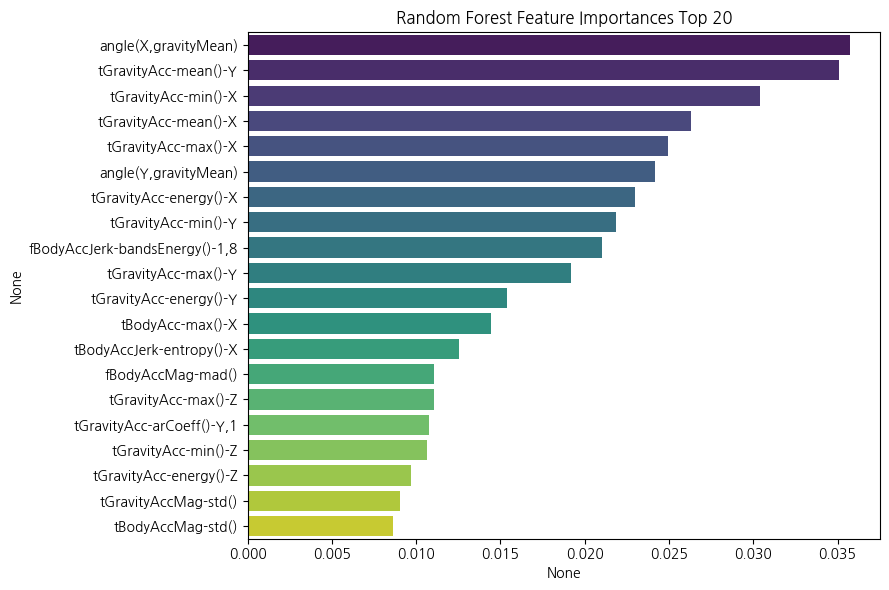

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#피처 중요도 시각화 : 중요도가 낮은 피치 제거 > 과적합 방지, 속도 향상

ftr_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20] #피처 중요도 내림차순 정렬, 상위 20개의 피치 선택

plt.figure(figsize=(9, 6))
plt.title('Random Forest Feature Importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index, palette='viridis')
plt.tight_layout()
plt.show()

In [ ]:
ftr_importances

,0
tBodyAcc-mean()-X,0.000206
tBodyAcc-mean()-Y,0.000249
tBodyAcc-mean()-Z,0.000165
tBodyAcc-std()-X,0.004376
tBodyAcc-std()-Y,0.000427
...,...
"angle(tBodyGyroMean,gravityMean)",0.000486
"angle(tBodyGyroJerkMean,gravityMean)",0.000274
"angle(X,gravityMean)",0.035734
"angle(Y,gravityMean)",0.024171


In [ ]:
from sklearn.model_selection import GridSearchCV
#GridSearchCV로 최적 하이퍼파라미터 탐색

params = {
    'n_estimators' : [100],
    'max_depth' : [6, 8, 10, 12],
    'min_samples_leaf' : [8, 12, 18],
    'min_samples_split' : [8, 16, 20]
}
rf_clf_gs = RandomForestClassifier(random_state=0, n_jobs=-1) #n_jobs=-1 : 모든 cpu 코어 사용(병렬 처리)
grid_cv = GridSearchCV(rf_clf_gs, param_grid = params, cv=2, n_jobs=-1)
y_train_reshaped = y_train.values.ravel() #1차원 배열로 평탄화, GridSearchCV가 y 데이터를 처리하는 방식에 필요
grid_cv.fit(X_train, y_train_reshaped)

print('최적 하이퍼 파라미터 : \n', grid_cv.best_params_) #최적의 하이퍼파라미터 조합
print(f'최고 예측 정확도: {grid_cv.best_score_}')

최적 하이퍼 파라미터 : 
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9178454842219804


In [ ]:
#최적 파라미터로 최종 학습
rf_clf1 = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    min_samples_leaf = 8,
    min_samples_split = 8,
    random_state = 0
)
y_train_reshaper = y_train.values.ravel()
rf_clf1.fit(X_train, y_train_reshaped)
pred = rf_clf1.predict(X_test)
print(f'최적의 파라미터 랜덤 포레스트 정확도:{accuracy_score(y_test, pred)}')

최적의 파라미터 랜덤 포레스트 정확도:0.9165252799457075


### GBM(Gradient Boosting Machine) - 많은 시간 소요

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time

#사용자 행동 인식 데이터셋 사용
start_time = time.time()
gb_clf = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 0
)
gb_clf.fit(X_train, y_train_reshaped)
gb_pred = gb_clf.redict(X_test)

print(f'GBM 정확도:{accuracy_score(y_test, gb_pred)}')
print(f'GBM 수행 시간: {time.time() - start_time}')

In [ ]:
#GBM GridSearchCV(시간이 오래 걸림 - 참고용)
params = {
    'n_estimators' : [100, 500],
    'learning_rate' : [0.05, 0.1]
}
gb_clf_gs = GradientBoostingClassifier(random_state=0)
grid_cv = GridSearchCV(gb_clf_gs, params_grid=params, cv=2, verbose=1)#verbose=1: 간단한 진행 상황 메시지를 출력
grid_cv.fit(X_train, y_train_reshaped)

print('최적 파라미터:', grid_cv.best_params_)
print(f'최고 정확도 : {grid_cv.best_score_}')

gb_pred = grid_cv.best_estimator_.predict(X_test) #.best_estimator_속성에서 최적 모델을 가져와서
print(f'테스트셋 정확도 : {accuracy_score(y_test, gb_pred)}')